In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content
import os
if not os.path.exists('/content/cdt-alzheimer-screening'):
    !git clone https://github.com/wiambenadder/cdt-alzheimer-screening.git
%cd cdt-alzheimer-screening
!git pull 2>/dev/null
!pip install -q -r requirements.txt
import sys
sys.path.insert(0, '/content/cdt-alzheimer-screening')
print("setup ok")

Mounted at /content/drive
/content
Cloning into 'cdt-alzheimer-screening'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 142 (delta 72), reused 27 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (142/142), 672.08 KiB | 3.29 MiB/s, done.
Resolving deltas: 100% (72/72), done.
/content/cdt-alzheimer-screening
Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 152.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.8 MB/s eta 0:00:00
set

In [2]:
# Re-stage all rounds for error analysis on full test set
import shutil, time
from pathlib import Path

LOCAL_DATA_DIR = Path('/content/nhats_local')
LOCAL_DATA_DIR.mkdir(exist_ok=True)
DRIVE_DATA_DIR = Path('/content/drive/MyDrive/cdt-data/nhats_raw')

t0 = time.time()
for rf in sorted(DRIVE_DATA_DIR.iterdir()):
    if not rf.is_dir(): continue
    dst = LOCAL_DATA_DIR / rf.name
    if dst.exists() and len(list(dst.glob('*.tif'))) > 0:
        continue
    print(f"[copy] {rf.name}")
    shutil.copytree(rf, dst, dirs_exist_ok=True)
print(f"staged in {(time.time()-t0)/60:.1f} min")

import pandas as pd
drive_labels = pd.read_csv('/content/drive/MyDrive/cdt-data/labels.csv')
drive_labels['image_path'] = drive_labels['image_path'].str.replace(
    '/content/drive/MyDrive/cdt-data/nhats_raw/',
    '/content/nhats_local/', regex=False)
drive_labels.to_csv('/content/cdt_labels_local.csv', index=False)
print(f"Loaded {len(drive_labels):,} labels")

[copy] round_01
[copy] round_02
[copy] round_03
[copy] round_04
[copy] round_05
[copy] round_06
[copy] round_07
[copy] round_08
[copy] round_09
[copy] round_10
[copy] round_11
[copy] round_12
[copy] round_13
[copy] round_14
staged in 42.5 min
Loaded 59,417 labels


In [4]:
%%writefile /content/cdt-alzheimer-screening/src/data.py
"""NHATS CDT dataset."""
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

from .config import DataConfig, SEED, NUM_CLASSES, LABELS_CSV, RAW_IMAGES_DIR


class CDTDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, int(row["label"])


def load_labels(labels_csv=LABELS_CSV, images_dir=RAW_IMAGES_DIR,
                image_ext=".tif", score_column="cdt_score",
                id_column="participant_id"):
    df = pd.read_csv(labels_csv)
    df = df.rename(columns={score_column: "label", id_column: "participant_id"})
    if "image_path" not in df.columns:
        df["image_path"] = df["participant_id"].apply(
            lambda pid: str(images_dir / f"{pid}{image_ext}"))
    df = df[df["label"].between(0, NUM_CLASSES - 1)].copy()
    df["label"] = df["label"].astype(int)
    exists_mask = df["image_path"].apply(lambda p: Path(p).exists())
    df = df[exists_mask].reset_index(drop=True)
    return df


def stratified_split(df, cfg):
    train_df, temp_df = train_test_split(
        df, test_size=1 - cfg.train_ratio, stratify=df["label"], random_state=SEED)
    val_size = cfg.val_ratio / (cfg.val_ratio + cfg.test_ratio)
    val_df, test_df = train_test_split(
        temp_df, train_size=val_size, stratify=temp_df["label"], random_state=SEED)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def participant_disjoint_split(df, cfg):
    """Leak-safe split: every participant appears in exactly one split."""
    gss1 = GroupShuffleSplit(n_splits=1, train_size=cfg.train_ratio, random_state=SEED)
    train_idx, temp_idx = next(gss1.split(df, groups=df["participant_id"]))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df  = df.iloc[temp_idx].reset_index(drop=True)
    val_ratio_in_temp = cfg.val_ratio / (cfg.val_ratio + cfg.test_ratio)
    gss2 = GroupShuffleSplit(n_splits=1, train_size=val_ratio_in_temp, random_state=SEED)
    val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["participant_id"]))
    val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)
    train_ids = set(train_df["participant_id"])
    val_ids   = set(val_df["participant_id"])
    test_ids  = set(test_df["participant_id"])
    assert not (train_ids & val_ids), "train/val leak"
    assert not (train_ids & test_ids), "train/test leak"
    assert not (val_ids & test_ids), "val/test leak"
    print(f"[split] participant-disjoint:")
    print(f"  train: {len(train_df):,} clocks from {len(train_ids):,} participants")
    print(f"  val:   {len(val_df):,} clocks from {len(val_ids):,} participants")
    print(f"  test:  {len(test_df):,} clocks from {len(test_ids):,} participants")
    return train_df, val_df, test_df


def compute_class_weights(train_df):
    labels = train_df["label"].values
    classes = np.unique(labels)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=labels)
    full = np.ones(NUM_CLASSES, dtype=np.float32)
    for c, w in zip(classes, weights):
        full[c] = w
    return torch.tensor(full, dtype=torch.float32)


def make_weighted_sampler(train_df):
    counts = train_df["label"].value_counts().sort_index()
    sw = train_df["label"].apply(lambda y: 1.0 / counts[y]).values
    return WeightedRandomSampler(weights=sw, num_samples=len(sw), replacement=True)


def build_dataloaders(train_ds, val_ds, test_ds, cfg, sampler=None):
    shuffle_train = sampler is None
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=shuffle_train,
        sampler=sampler, num_workers=cfg.num_workers, pin_memory=True, drop_last=True,
        persistent_workers=(cfg.num_workers > 0))
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
        num_workers=cfg.num_workers, pin_memory=True,
        persistent_workers=(cfg.num_workers > 0))
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
        num_workers=cfg.num_workers, pin_memory=True,
        persistent_workers=(cfg.num_workers > 0))
    return train_loader, val_loader, test_loader

Overwriting /content/cdt-alzheimer-screening/src/data.py


In [5]:
import importlib
import src.config, src.data, src.augmentation, src.models, src.evaluate, src.utils
for m in [src.config, src.data, src.augmentation, src.models, src.evaluate, src.utils]:
    importlib.reload(m)

import src.config as cfg
cfg.LABELS_CSV  = Path('/content/cdt_labels_local.csv')
cfg.MODELS_DIR  = Path('/content/drive/MyDrive/cdt-data/models')
cfg.RESULTS_DIR = Path('/content/drive/MyDrive/cdt-data/results')

from src.data import participant_disjoint_split, CDTDataset
from src.config import DataConfig
from src.augmentation import build_eval_transform
from torch.utils.data import DataLoader

df = pd.read_csv(cfg.LABELS_CSV)
df = df.rename(columns={'cdt_score': 'label'})[['participant_id', 'label', 'image_path']]
df['participant_id'] = df['participant_id'].astype(str)
data_cfg = DataConfig(batch_size=32, num_workers=4)

# Same SEED → same splits as notebook 03
train_df, val_df, test_df = participant_disjoint_split(df, data_cfg)

eval_tf = build_eval_transform(data_cfg.image_size)
test_ds = CDTDataset(test_df, transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4,
                         pin_memory=True, persistent_workers=True, prefetch_factor=4)
print(f"\n[ok] test set: {len(test_df):,} clocks ready for analysis")

[split] participant-disjoint:
  train: 41,551 clocks from 9,549 participants
  val:   8,928 clocks from 2,046 participants
  test:  8,938 clocks from 2,047 participants

[ok] test set: 8,938 clocks ready for analysis


In [6]:
import torch
from src.models import get_model
from src.utils import load_checkpoint, get_device

device = get_device()
ckpt_path = cfg.MODELS_DIR / 'vit_b16_ft_best.pt'
print(f"Loading: {ckpt_path}")

model, _, _ = get_model('vit_b16', freeze_backbone=False, dropout=0.3)
model = load_checkpoint(model, str(ckpt_path), device=device).to(device)
model.eval()
print(f"[ok] ViT-B/16 loaded ({sum(p.numel() for p in model.parameters()):,} params)")

Loading: /content/drive/MyDrive/cdt-data/models/vit_b16_ft_best.pt
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 246MB/s]


[ok] ViT-B/16 loaded (85,803,270 params)


In [7]:
from src.evaluate import collect_predictions
import numpy as np

print("Running ViT over test set...")
y_true, y_pred, y_probs = collect_predictions(model, test_loader, device)
print(f"Predictions: {len(y_pred):,}")
print(f"Distribution of predicted classes: {np.bincount(y_pred, minlength=6).tolist()}")
print(f"Distribution of true classes:      {np.bincount(y_true, minlength=6).tolist()}")

Running ViT over test set...
Predictions: 8,938
Distribution of predicted classes: [103, 389, 1288, 1791, 2599, 2768]
Distribution of true classes:      [94, 323, 996, 1976, 3187, 2362]


In [8]:
from src.evaluate import plot_confusion_matrix, save_classification_report

# Raw counts
plot_confusion_matrix(y_true, y_pred,
                      cfg.RESULTS_DIR / 'vit_confusion_matrix.png',
                      normalize=False)
print(f"saved: vit_confusion_matrix.png")

# Normalized (per-class recall) — easier to interpret
plot_confusion_matrix(y_true, y_pred,
                      cfg.RESULTS_DIR / 'vit_confusion_matrix_normalized.png',
                      normalize=True)
print(f"saved: vit_confusion_matrix_normalized.png")

# Detailed per-class report
save_classification_report(y_true, y_pred,
                           cfg.RESULTS_DIR / 'vit_classification_report.json')

# Print human-readable version
from sklearn.metrics import classification_report
print("\n" + classification_report(y_true, y_pred,
    labels=list(range(6)),
    target_names=['0_severe', '1_significant', '2_moderate', '3_mild_mod',
                  '4_mild', '5_normal'],
    zero_division=0))

saved: vit_confusion_matrix.png
saved: vit_confusion_matrix_normalized.png

               precision    recall  f1-score   support

     0_severe       0.57      0.63      0.60        94
1_significant       0.59      0.71      0.64       323
   2_moderate       0.53      0.69      0.60       996
   3_mild_mod       0.69      0.62      0.65      1976
       4_mild       0.74      0.61      0.67      3187
     5_normal       0.68      0.79      0.73      2362

     accuracy                           0.67      8938
    macro avg       0.63      0.67      0.65      8938
 weighted avg       0.68      0.67      0.67      8938



In [9]:
from src.evaluate import analyze_errors
from pathlib import Path

errors_dir = cfg.RESULTS_DIR / 'errors'
errors_dir.mkdir(parents=True, exist_ok=True)

records = analyze_errors(
    y_true, y_pred, y_probs,
    df_test=test_df.reset_index(drop=True),
    save_dir=errors_dir,
    k=12,
)
print(f"\nSaved {len(records)} error examples to {errors_dir}/")
print("\nTop misclassifications:")
import pandas as pd
print(pd.DataFrame(records)[['true_label', 'pred_label', 'pred_confidence', 'ordinal_distance']]
      .head(12).to_string())


Saved 12 error examples to /content/drive/MyDrive/cdt-data/results/errors/

Top misclassifications:
    true_label  pred_label  pred_confidence  ordinal_distance
0            1           0         0.996119                 1
1            3           1         0.988242                 2
2            3           2         0.982709                 1
3            3           2         0.981279                 1
4            2           3         0.976093                 1
5            3           2         0.976035                 1
6            1           2         0.973787                 1
7            3           2         0.973283                 1
8            3           2         0.970919                 1
9            0           1         0.970352                 1
10           3           2         0.969810                 1
11           3           2         0.969575                 1


In [10]:
from src.evaluate import measure_inference_time

print("Measuring inference throughput...")
timing = measure_inference_time(model, test_loader, device, n_batches=20)
print(f"\nViT-B/16 inference: {timing['ms_per_image']:.1f} ms/image")
print(f"                    {timing['images_per_sec']:.0f} images/sec")
print(f"\nThis matters for clinical deployment - a clock takes <1 second to score.")

Measuring inference throughput...

ViT-B/16 inference: 2.3 ms/image
                    436 images/sec

This matters for clinical deployment - a clock takes <1 second to score.


Generating occlusion-based attribution maps for ViT...
(This iterates 196 patches per image — about 90 seconds each)

  class 0 (10000134)...
  class 1 (10000620)...
  class 2 (10000076)...
  class 3 (10000003)...
  class 4 (10000192)...
  class 5 (10000055)...


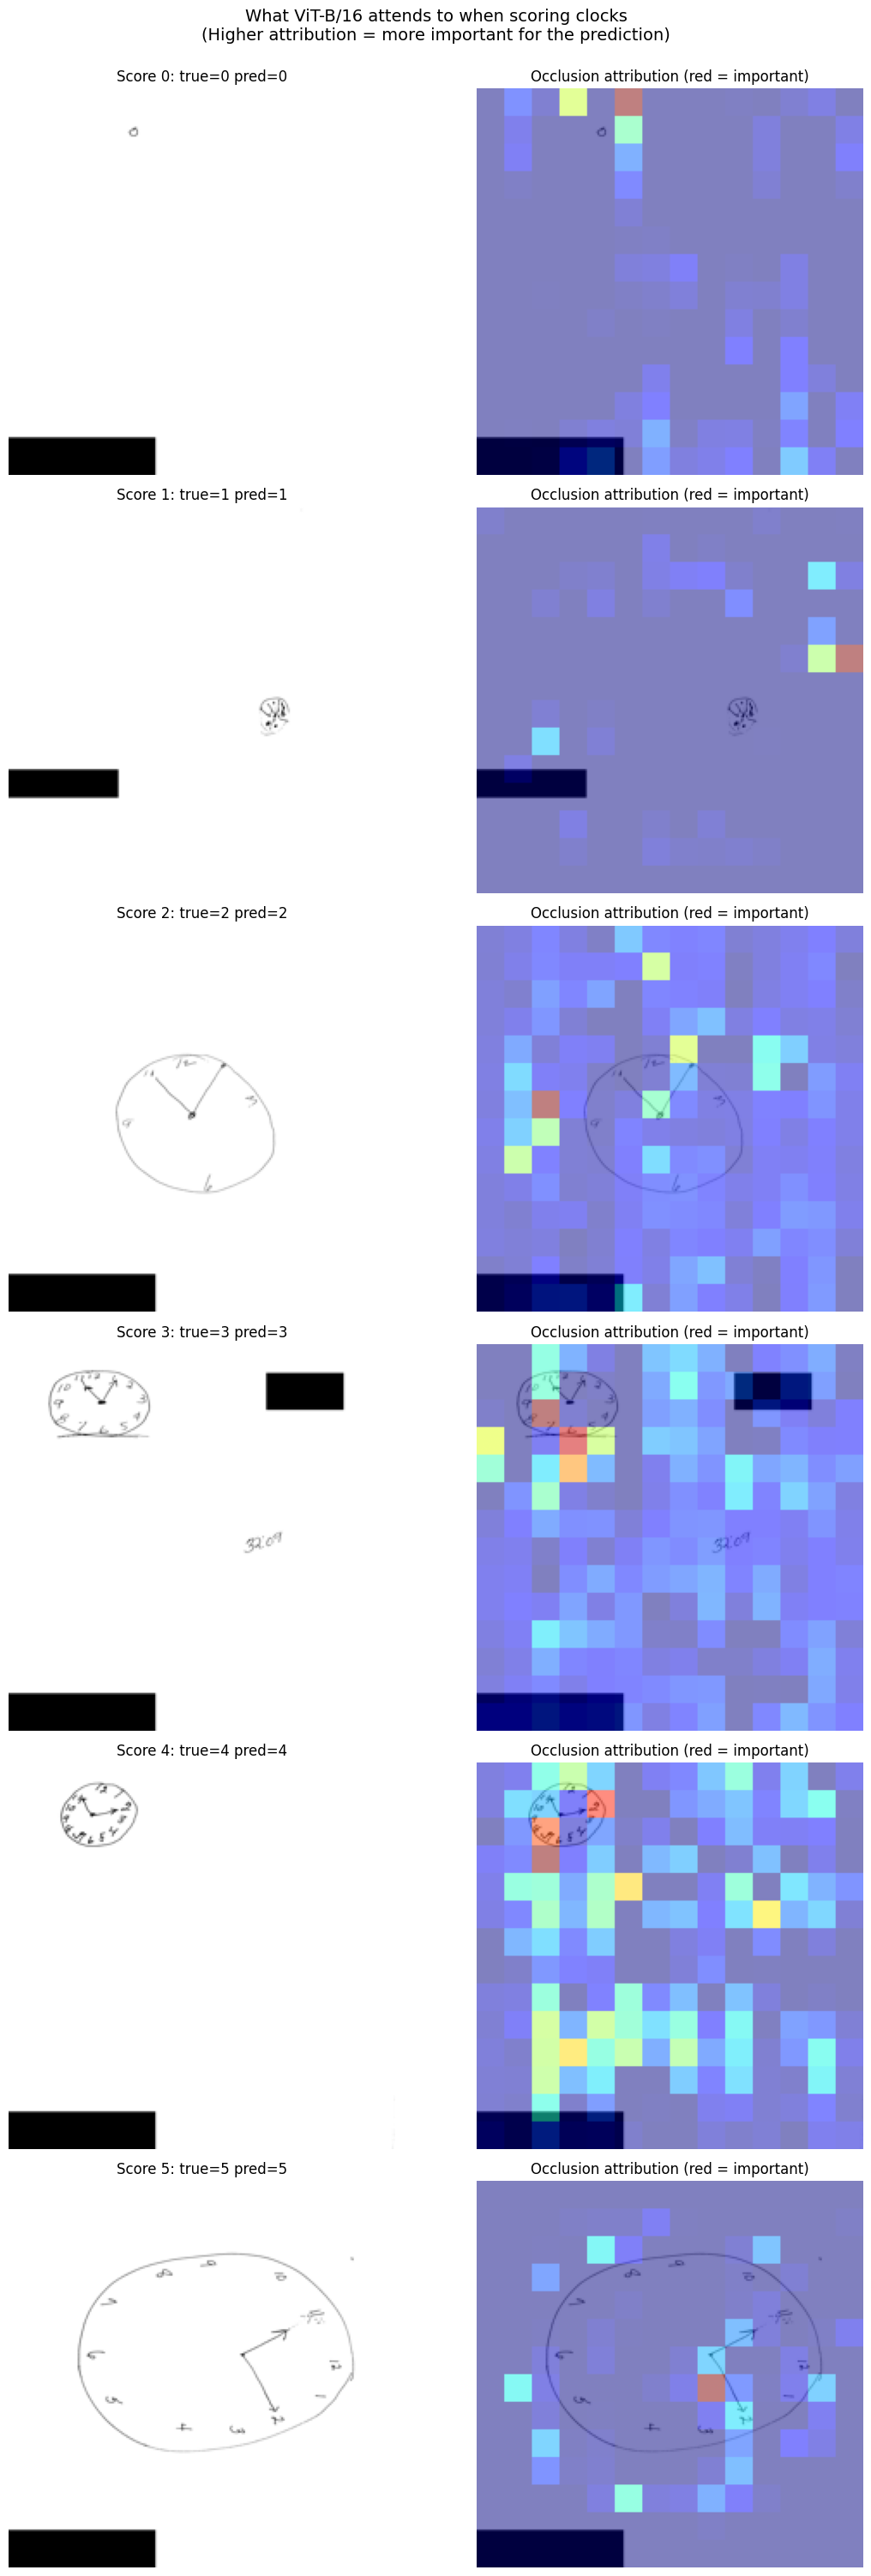


Saved: /content/drive/MyDrive/cdt-data/results/vit_attribution_maps.png


In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from src.gradcam import vit_occlusion_map
from src.augmentation import build_eval_transform

eval_tf = build_eval_transform(224)

# Pick one example per CDT class — preferring correctly classified ones
samples = []
for cls in range(6):
    correct_idx = np.where((y_true == cls) & (y_pred == cls))[0]
    if len(correct_idx) > 0:
        idx = correct_idx[0]
    else:
        idx = np.where(y_true == cls)[0][0]  # fallback: any example of this class
    samples.append((cls, idx))

# Generate occlusion maps for ViT (true Grad-CAM doesn't work for transformers)
print("Generating occlusion-based attribution maps for ViT...")
print("(This iterates 196 patches per image — about 90 seconds each)\n")

fig, axes = plt.subplots(6, 2, figsize=(12, 30))
for row, (cls, idx) in enumerate(samples):
    img_path = test_df.iloc[idx]['image_path']
    img = Image.open(img_path).convert('RGB')
    x = eval_tf(img).unsqueeze(0).to(device)

    print(f"  class {cls} ({test_df.iloc[idx]['participant_id']})...")
    heatmap = vit_occlusion_map(model, x, patch_size=16,
                                class_idx=int(y_pred[idx]))

    # Resize heatmap to match the input image (224x224)
    heatmap_resized = np.kron(heatmap, np.ones((16, 16)))

    # Original
    axes[row, 0].imshow(np.array(img.resize((224, 224))), cmap='gray')
    axes[row, 0].set_title(f'Score {cls}: true={y_true[idx]} pred={y_pred[idx]}')
    axes[row, 0].axis('off')

    # Overlay
    axes[row, 1].imshow(np.array(img.resize((224, 224))), cmap='gray')
    axes[row, 1].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    axes[row, 1].set_title(f'Occlusion attribution (red = important)')
    axes[row, 1].axis('off')

plt.suptitle('What ViT-B/16 attends to when scoring clocks\n'
             '(Higher attribution = more important for the prediction)',
             fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(cfg.RESULTS_DIR / 'vit_attribution_maps.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nSaved: {cfg.RESULTS_DIR / 'vit_attribution_maps.png'}")

In [12]:
import pandas as pd
import json

results = {}
for fn in ['baselines.json', 'finetuning_results.json', 'ablation_results.json']:
    p = cfg.RESULTS_DIR / fn
    if p.exists():
        with open(p) as f:
            results.update(json.load(f))

rows = []
for name, m in results.items():
    if isinstance(m, dict):
        rows.append({
            'run': name,
            'accuracy': m.get('accuracy'),
            'macro_f1': m.get('macro_f1'),
            'quadratic_kappa': m.get('quadratic_kappa'),
            'macro_auc': m.get('macro_auc'),
            'note': m.get('note', ''),
        })

df_all = pd.DataFrame(rows).set_index('run')
df_all = df_all.sort_values('quadratic_kappa', ascending=False, na_position='last')
df_all.to_csv(cfg.RESULTS_DIR / 'all_results.csv')
print("=" * 100)
print("ALL RESULTS — sorted by quadratic kappa")
print("=" * 100)
print(df_all.round(4).to_string())
print(f"\nSaved to {cfg.RESULTS_DIR / 'all_results.csv'}")

ALL RESULTS — sorted by quadratic kappa
                    accuracy  macro_f1  quadratic_kappa  macro_auc                                                note
run                                                                                                                   
abl_unfrozen_aug      0.6760    0.6555           0.8117     0.9257                                                    
vit_b16_ft            0.6719    0.6484           0.8085     0.9253                                                    
abl_unfrozen_noaug    0.6457    0.6227           0.7992     0.9156                                                    
vgg16_ft              0.6160    0.5842           0.7813     0.9026  trained 8 epochs, stopped manually for time budget
effb0_ft              0.5895    0.5493           0.7465     0.8932                                                    
abl_frozen_noaug      0.5015    0.4942           0.6670     0.8489                                                    
abl_froz